In [205]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

df = pd.read_excel('C:/Users/sudet/Downloads/210/final_dataset.xlsx')
df.dropna(inplace=True)

In [206]:
df.drop(columns=['Description'], inplace=True)
df['Amount'] = df['Amount'].abs()
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')

# Extract day, month, and year from 'Date' column
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.drop(columns=['Date'], inplace=True)

print(df.head())

   Time   Amount   Balance   Category  Emotional State  Day  Month  Year
0    23   257.99  17224.27  thrifting  strong positive   25     10  2024
1    19  1939.95  17482.26   clothing  strong positive   25     10  2024
2    15    70.00  19422.21       food  strong positive   25     10  2024
3    12    32.00  19492.21     market  strong positive   25     10  2024
4    12    20.00  19524.21      other  strong positive   25     10  2024


In [207]:
category_counts = df['Category'].value_counts()
print(category_counts)

Category
food                   194
other                  162
market                  59
transportation          56
investment              43
subscription            40
clothing                33
social                  30
thrifting               13
skincare                13
credit card payment     12
make-up                 11
education               10
travel cost              3
Name: count, dtype: int64


In [208]:
# keep only the specified categories
categories_to_keep = ['food', 'subscription','investment', 'transportation']
df = df[df['Category'].isin(categories_to_keep)]

print(df.head())

    Time  Amount   Balance Category  Emotional State  Day  Month  Year
2     15    70.0  19422.21     food  strong positive   25     10  2024
5     22    20.0  19544.21     food          neutral   24     10  2024
6     22   120.0  19564.21     food          neutral   24     10  2024
9     15    50.0  21508.34     food  mildly positive   23     10  2024
10    13   175.0  21558.34     food  mildly positive   23     10  2024


In [ ]:
# one-hot encoding on the 'Emotional State' column
df = pd.get_dummies(df, columns=['Emotional State'])

print(df.head())

    Time  Amount   Balance Category  Day  Month  Year  \
2     15    70.0  19422.21     food   25     10  2024   
5     22    20.0  19544.21     food   24     10  2024   
6     22   120.0  19564.21     food   24     10  2024   
9     15    50.0  21508.34     food   23     10  2024   
10    13   175.0  21558.34     food   23     10  2024   

    Emotional State_mildly negative  Emotional State_mildly positive  \
2                             False                            False   
5                             False                            False   
6                             False                            False   
9                             False                             True   
10                            False                             True   

    Emotional State_negative  Emotional State_neutral  \
2                      False                    False   
5                      False                     True   
6                      False                     True

In [210]:
category_counts = df['Category'].value_counts()
print(category_counts)

Category
food              194
transportation     56
investment         43
subscription       40
Name: count, dtype: int64


In [211]:
df = df[~df['Category'].isin(['education', 'travel cost', 'credit card payment', 'thrifting', 'make-up', 'skincare', 'other'])]
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])
category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
df

,Time,Amount,Balance,Category,Day,Month,Year,Emotional State_mildly negative,Emotional State_mildly positive,Emotional State_negative,Emotional State_neutral,Emotional State_positive,Emotional State_strong negative,Emotional State_strong positive
2,15,70.00,19422.21,0,25,10,2024,False,False,False,False,False,False,True
5,22,20.00,19544.21,0,24,10,2024,False,False,False,True,False,False,False
6,22,120.00,19564.21,0,24,10,2024,False,False,False,True,False,False,False
9,15,50.00,21508.34,0,23,10,2024,False,True,False,False,False,False,False
10,13,175.00,21558.34,0,23,10,2024,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696,14,13.00,1912.00,0,3,1,2023,False,False,False,False,True,False,False
697,1,179.00,1885.00,0,3,1,2023,False,False,False,False,True,False,False
698,14,65.00,1920.00,3,2,1,2023,False,False,False,False,True,False,False
700,12,2500.00,2000.00,1,2,1,2023,False,False,False,False,True,False,False


In [ ]:
df['Amount'] = df['Amount'].abs()
df['Time'] = df['Time'].astype(int) 
df['Day'] = df['Day'].astype(int) 
df['Month'] = df['Month'].astype(int)  
df['Year'] = df['Year'].astype(int)  
df['Emotional State_mildly negative'] = df['Emotional State_mildly negative'].astype(int)
df['Emotional State_mildly positive'] = df['Emotional State_mildly positive'].astype(int)  
df['Emotional State_negative'] = df['Emotional State_negative'].astype(int) 
df['Emotional State_neutral'] = df['Emotional State_neutral'].astype(int)  
df['Emotional State_positive'] = df['Emotional State_positive'].astype(int)  
df['Emotional State_strong negative'] = df['Emotional State_strong negative'].astype(int)  
df['Emotional State_strong positive'] = df['Emotional State_strong positive'].astype(int)
df

,Time,Amount,Balance,Category,Day,Month,Year,Emotional State_mildly negative,Emotional State_mildly positive,Emotional State_negative,Emotional State_neutral,Emotional State_positive,Emotional State_strong negative,Emotional State_strong positive
2,15,70.00,19422.21,0,25,10,2024,0,0,0,0,0,0,1
5,22,20.00,19544.21,0,24,10,2024,0,0,0,1,0,0,0
6,22,120.00,19564.21,0,24,10,2024,0,0,0,1,0,0,0
9,15,50.00,21508.34,0,23,10,2024,0,1,0,0,0,0,0
10,13,175.00,21558.34,0,23,10,2024,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696,14,13.00,1912.00,0,3,1,2023,0,0,0,0,1,0,0
697,1,179.00,1885.00,0,3,1,2023,0,0,0,0,1,0,0
698,14,65.00,1920.00,3,2,1,2023,0,0,0,0,1,0,0
700,12,2500.00,2000.00,1,2,1,2023,0,0,0,0,1,0,0


In [213]:
X = df.drop(columns=["Category"])
y = df["Category"]

In [214]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# evaluate on test set
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=[str(key) for key in category_mapping.keys()]))

# perform cross-validation
cv_scores = cross_val_score(clf, X, y, cv=20, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())


Classification Report:
                 precision    recall  f1-score   support

          food       0.83      1.00      0.91        44
    investment       0.67      0.80      0.73         5
  subscription       1.00      1.00      1.00         7
transportation       1.00      0.09      0.17        11

      accuracy                           0.84        67
     macro avg       0.87      0.72      0.70        67
  weighted avg       0.86      0.84      0.78        67

Cross-validation scores: [0.82352941 0.82352941 0.94117647 0.82352941 0.82352941 0.82352941
 0.88235294 0.82352941 0.70588235 0.76470588 0.94117647 0.76470588
 0.88235294 0.8125     0.75       0.875      0.875      0.9375
 0.9375     0.9375    ]
Mean accuracy: 0.8474264705882353


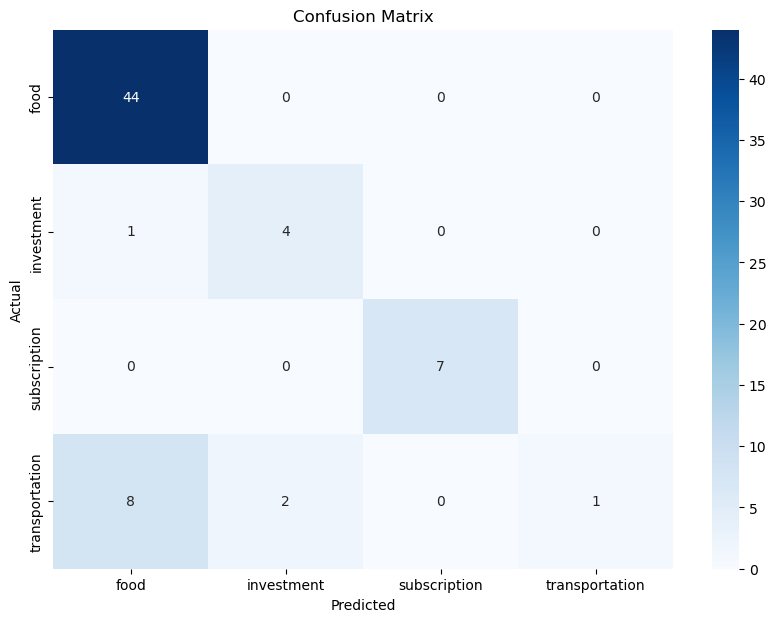

In [216]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=category_mapping.keys(), yticklabels=category_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
df = pd.read_excel('C:/Users/sudet/Downloads/210/final_dataset.xlsx')
df.dropna(inplace=True)

df.drop(columns=['Description'], inplace=True)
df['Amount'] = df['Amount'].abs()
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour 

df = df[~df['Category'].isin(['education', 'travel cost', 'credit card payment', 'thrifting', 'make-up', 'skincare', 'other'])]

le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])  # encode category for prediction
category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))  # to decode predictions later

df['Amount'] = df['Amount'].abs()
df['Date'] = pd.to_datetime(df['Date']) 
df['Time'] = df['Time'].astype(int)
df['Emotional State'] = df['Emotional State'].replace(
    {'strong positive': 'positive', 'mildly positive': 'positive',
     'strong negative': 'negative', 'mildly negative': 'negative'}
)
df['Emotional State'] = le.fit_transform(df['Emotional State'])

# separate features and target
X = df[['Time', 'Amount', 'Balance', 'Emotional State']]
y = df['Category']

# scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#initialize RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

# evaluate on test set
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=[str(key) for key in category_mapping.keys()]))

# perform cross-validation
cv_scores = cross_val_score(clf, X, y, cv=20, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

C:\Users\sudet\AppData\Local\Temp\ipykernel_22144\2134617148.py:10: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])
c:\Users\sudet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sudet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sudet\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: Undef

Classification Report:
                 precision    recall  f1-score   support

      clothing       0.45      0.71      0.56         7
          food       0.59      0.88      0.71        34
    investment       0.67      0.80      0.73         5
        market       0.67      0.33      0.44        12
        social       0.00      0.00      0.00        11
  subscription       1.00      1.00      1.00        12
transportation       0.60      0.30      0.40        10

      accuracy                           0.64        91
     macro avg       0.57      0.58      0.55        91
  weighted avg       0.58      0.64      0.58        91

Cross-validation scores: [0.7826087  0.69565217 0.65217391 0.7826087  0.56521739 0.73913043
 0.65217391 0.56521739 0.60869565 0.34782609 0.52173913 0.34782609
 0.56521739 0.52173913 0.60869565 0.68181818 0.59090909 0.63636364
 0.63636364 0.72727273]
Mean accuracy: 0.6114624505928854


In [245]:
df = pd.read_excel('C:/Users/sudet/Downloads/210/final_dataset.xlsx')
df.dropna(inplace=True)
df.drop(columns=['Description'], inplace=True)

le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])
df['Amount'] = df['Amount'].abs()
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour  

df['Emotional State'] = df['Emotional State'].replace(
    {'strong positive': 'positive', 'mildly positive': 'positive', 
     'strong negative': 'negative', 'mildly negative': 'negative'}
)

df['Emotional State'] = le.fit_transform(df['Emotional State'])


X = df.drop(columns=['Emotional State', 'Date'])  # Drop target and non-numeric features
y = df['Emotional State']

scaler = StandardScaler()
X[['Amount', 'Balance', 'Time']] = scaler.fit_transform(X[['Amount', 'Balance', 'Time']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:\n", feature_importance)


C:\Users\sudet\AppData\Local\Temp\ipykernel_22144\2714225702.py:17: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


Accuracy: 0.49264705882352944

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.53      0.51        49
           1       0.40      0.19      0.26        32
           2       0.51      0.64      0.57        55

    accuracy                           0.49       136
   macro avg       0.47      0.45      0.44       136
weighted avg       0.48      0.49      0.47       136


Feature Importance:
     Feature  Importance
2   Balance    0.399793
1    Amount    0.280537
0      Time    0.194014
3  Category    0.125657
